In [2]:
pip install numpy matplotlib torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.8/114.6 MB 1.8 MB/s eta 0:01:03
   ---------------------------------------- 1.0/114.6 MB 1.8 MB/s eta 0:01:02
    --------------------------------------- 1.6/114.6 MB 2.0 MB/s eta 0:00:57
    --------------------------------------- 2.1/114.6 MB 2.1 MB/s eta 0:00:54
    --------------------------------------- 2.4/114.6 MB 2.0 MB/s eta 0:00:56
   - -------------------------------------- 2.9/114.6 MB 2.1 MB/s eta 0:00:54
   - -------------------------------------- 3.4/114.6 MB 2.1 MB/s eta 0:00:53
   - -------------------------------------- 3.9/114.6 MB 2.2 MB/s eta 0:00:51
   - -------------------------------------- 4.5/114.6 MB 2.2 MB/s eta 0:00:50
   - ---------

In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

In [2]:
class ResourceEnv:
    def __init__(self, num_users=3, total_resource=10):
        self.num_users = num_users
        self.total_resource = total_resource

    def reset(self):
        self.demand = np.random.randint(1, 6, size=self.num_users)
        return self._get_state()

    def _get_state(self):
        return self.demand / 5.0  # normalize

    def step(self, action):
        allocation = self._decode_action(action)

        throughput = np.sum(np.minimum(allocation, self.demand))
        fairness = np.std(allocation)

        reward = throughput - 0.5 * fairness

        self.demand = np.random.randint(1, 6, size=self.num_users)
        next_state = self._get_state()

        return next_state, reward

    def _decode_action(self, action):
        # Predefined actions
        action_space = [
            [3,3,4],
            [4,3,3],
            [3,4,3],
            [5,3,2],
            [2,5,3],
            [3,2,5],
            [3,3,3],
        ]
        return np.array(action_space[action])


In [3]:
# DQN NETWORK
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )

    def forward(self, x):
        return self.net(x)


In [4]:
# AGENT
class Agent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        self.memory = deque(maxlen=5000)

        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.05
        self.lr = 0.001

        self.model = DQN(state_size, action_size)
        self.target_model = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        self.update_target()

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def remember(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.action_size)

        state = torch.FloatTensor(state)
        q_values = self.model(state)
        return torch.argmax(q_values).item()

    def replay(self, batch_size=32):
        if len(self.memory) < batch_size:
            return

        batch = random.sample(self.memory, batch_size)

        for state, action, reward, next_state in batch:
            state = torch.FloatTensor(state)
            next_state = torch.FloatTensor(next_state)

            target = reward
            target += self.gamma * torch.max(self.target_model(next_state)).item()

            current_q = self.model(state)
            target_q = current_q.clone().detach()
            target_q[action] = target

            loss = nn.MSELoss()(current_q, target_q)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [5]:
# TRAINING
def train():
    env = ResourceEnv()
    state_size = env.num_users
    action_size = 7

    agent = Agent(state_size, action_size)

    episodes = 500
    rewards = []

    for e in range(episodes):
        state = env.reset()
        total_reward = 0

        for t in range(20):
            action = agent.act(state)
            next_state, reward = env.step(action)

            agent.remember(state, action, reward, next_state)
            agent.replay()

            state = next_state
            total_reward += reward

        agent.update_target()
        rewards.append(total_reward)

        print(f"Episode {e+1}, Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

    return rewards

In [7]:
# BASELINE COMPARISON
def random_policy():
    env = ResourceEnv()
    total = 0

    for _ in range(500):
        env.reset()
        for _ in range(20):
            action = random.randint(0,6)
            _, reward = env.step(action)
            total += reward

    return total / 500


Episode 1, Reward: 142.49, Epsilon: 1.000
Episode 2, Reward: 142.02, Epsilon: 0.956
Episode 3, Reward: 131.36, Epsilon: 0.865
Episode 4, Reward: 146.21, Epsilon: 0.782
Episode 5, Reward: 146.51, Epsilon: 0.708
Episode 6, Reward: 141.58, Epsilon: 0.640
Episode 7, Reward: 141.68, Epsilon: 0.579
Episode 8, Reward: 137.73, Epsilon: 0.524
Episode 9, Reward: 141.35, Epsilon: 0.474
Episode 10, Reward: 161.05, Epsilon: 0.429
Episode 11, Reward: 137.07, Epsilon: 0.388
Episode 12, Reward: 155.90, Epsilon: 0.351
Episode 13, Reward: 136.61, Epsilon: 0.317
Episode 14, Reward: 129.82, Epsilon: 0.287
Episode 15, Reward: 130.58, Epsilon: 0.260
Episode 16, Reward: 152.65, Epsilon: 0.235
Episode 17, Reward: 154.67, Epsilon: 0.212
Episode 18, Reward: 145.03, Epsilon: 0.192
Episode 19, Reward: 153.04, Epsilon: 0.174
Episode 20, Reward: 134.90, Epsilon: 0.157
Episode 21, Reward: 149.51, Epsilon: 0.142
Episode 22, Reward: 140.42, Epsilon: 0.129
Episode 23, Reward: 135.07, Epsilon: 0.116
Episode 24, Reward: 

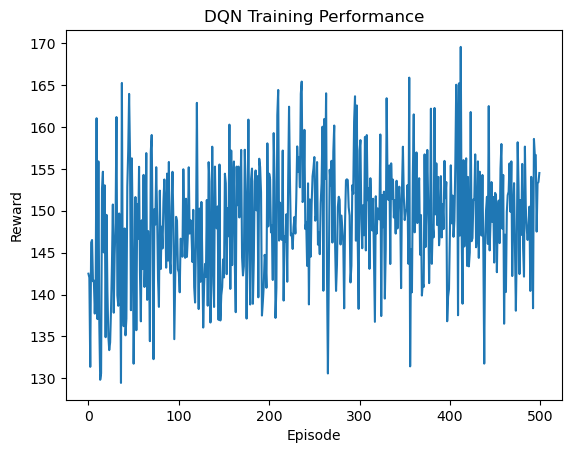

In [8]:
# MAIN
if __name__ == "__main__":
    rewards = train()
    baseline = random_policy()

    print("\nRandom Policy Average Reward:", baseline)

    plt.plot(rewards)
    plt.title("DQN Training Performance")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.show()